***The Operational Data Cleaner&Insight Generator***

**import relevant libraries**


In [1]:
#import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the sensor dataset
sensor_df = pd.read_csv("D:\INUKA TECH WORK\WeekTwoWork\week2_sensor_readings.csv")
#print the first 5 rows
sensor_df.head()

,timestamp,sensor_id,reading,location,shift
0,01/06/2026 00:00,Pressure_01,54.967142,mombasa,Afternoon
1,01/06/2026 00:05,Pressure_01,48.617357,NRB,Morning
2,01/06/2026 00:10,temp_sensor,56.476885,Nairobi,Morning
3,01/06/2026 00:15,P1,65.230299,mombasa,Morning
4,01/06/2026 00:20,P1,47.658466,mombasa,Night


In [3]:
#profile the data using  .info() , .describe()
sensor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2000 non-null   object 
 1   sensor_id  2000 non-null   object 
 2   reading    2000 non-null   float64
 3   location   2000 non-null   object 
 4   shift      2000 non-null   object 
dtypes: float64(1), object(4)
memory usage: 78.3+ KB


In [4]:
#use describe()
sensor_df.describe()

,reading
count,2000.000000
mean,50.450841
std,9.884657
min,17.587327
25%,43.773381
50%,50.446917
75%,56.829776
max,88.527315


**Generate a "Data Health Report" in Markdown identifying at least 3 specific quality issues.**

## Data Health Report

Based on the initial profiling of the `sensor_df`, the following data quality issues have been identified:

1.  **Incorrect Data Type for `timestamp` column**:
    *   **Issue**: The `timestamp` column is currently of `object` (string) data type, as indicated by `sensor_df.info()`. For time-series analysis and proper date-based operations, this column should be converted to a datetime format.
    *   **Impact**: Prevents direct time-based filtering, sorting, and aggregations, and can lead to errors in time-series modeling.

2.  **Inconsistent Naming Conventions in `sensor_id` column**:
    *   **Issue**: The `sensor_id` column contains entries with varying naming conventions, such as `Pressure_01`, `temp_sensor`, `P1`, and `TEMP_SENS`. This lack of standardization suggests that different representations might refer to the same or similar sensor types.
    *   **Impact**: Makes it difficult to accurately group and analyze data by sensor type, leading to fragmented or incorrect insights.

3.  **Inconsistent Naming Conventions in `location` column**:
    *   **Issue**: The `location` column exhibits inconsistencies in how locations are recorded. Examples include `mombasa`, `NRB`, and `Nairobi`. These likely refer to the same or similar geographical areas but are represented differently.
    *   **Impact**: Aggregations or filtering based on location will be inaccurate unless these inconsistencies are resolved, leading to misrepresentation of data distribution across different locations.

In [5]:
def clean_ops_data(df):
    """
    Cleans the operational sensor data DataFrame.
    Args:
        df (pd.DataFrame): The input DataFrame containing sensor readings.
    Returns:
        pd.DataFrame: The cleaned DataFrame.
    """

    # Make a copy to avoid modifying the original DataFrame
    sensor_cleaned_df = df.copy()

    # 1. Convert timestamps to datetime objects
    sensor_cleaned_df['timestamp'] = pd.to_datetime(sensor_cleaned_df['timestamp'], format='%d/%m/%Y %H:%M')

    # 2. Handle missing values
    # Justification: For 'reading' (numerical, time-series), interpolation is often preferred
    # to maintain the temporal sequence. For other columns, dropping rows with NaNs is a
    # general approach if missing data is sparse and imputation is not straightforward.

    # Sort by timestamp for proper interpolation
    sensor_cleaned_df = sensor_cleaned_df.sort_values(by='timestamp').reset_index(drop=True)

    # Interpolate missing 'reading' values
    if sensor_cleaned_df['reading'].isnull().any():
        print("Missing 'reading' values detected. Interpolating...")
        sensor_cleaned_df['reading'] = sensor_cleaned_df['reading'].interpolate(method='linear')

    # Drop any remaining missing values in other columns
    if sensor_cleaned_df.isnull().sum().sum() > 0:
        print("Warning: Remaining missing values detected in other columns. Dropping rows with any NaN.")
        sensor_cleaned_df.dropna(inplace=True)

    # 3. Remove duplicates
    initial_rows = len(sensor_cleaned_df)
    sensor_cleaned_df.drop_duplicates(inplace=True)
    if len(sensor_cleaned_df) < initial_rows:
        print(f"Removed {initial_rows - len(sensor_cleaned_df)} duplicate rows.")

    # 4. Standardize categorical columns
    # Standardize 'sensor_id'
    sensor_cleaned_df['sensor_id'] = sensor_cleaned_df['sensor_id'].str.lower().replace({
   'p1': 'Pressure_sensor_01',
    'pressure_01':'Pressure_sensor_01',
    'p2': 'Pressure_sensor_02',
    'temp_sensor': 'Temperature_sensor',
    'temp_sens': 'Temperature_sensor'
    })
    # Standardize 'location'
    sensor_cleaned_df['location'] = sensor_cleaned_df['location'].str.lower().replace({
        'nrb': 'Nairobi',
        'nairobi': 'Nairobi',
        'mba': 'Mombasa',
        'mombasa': 'Mombasa',
        'kisumu':'Kisumu'
    })
    # Standardize 'shift'
    sensor_cleaned_df['shift'] = sensor_cleaned_df['shift'].str.lower()
    # 5. Filters out physically impossible sensor readings (outliers)
    # Assuming sensor readings should be within a plausible range, e.g., 0 to 100.
    # This range can be adjusted based on domain knowledge.
    min_reading = 0
    max_reading = 100
    outliers_before = len(sensor_cleaned_df[(sensor_cleaned_df['reading'] < min_reading) | (sensor_cleaned_df['reading'] > max_reading)])
    sensor_cleaned_df = sensor_cleaned_df[(sensor_cleaned_df['reading'] >= min_reading) & (sensor_cleaned_df['reading'] <= max_reading)]
    if outliers_before > 0:
        print(f"Removed {outliers_before} outlier readings outside the range [{min_reading}, {max_reading}].")

    return sensor_cleaned_df

**Applying the Cleaning Pipeline**

In [6]:
# Apply the cleaning function to the original DataFrame
cleaned_sensor_df = clean_ops_data(sensor_df)

print("Cleaned DataFrame First Five Rows:")
display(cleaned_sensor_df.head(5))

print("\nCleaned DataFrame Info:")
cleaned_sensor_df.info()

print("\nCleaned DataFrame Description:")
display(cleaned_sensor_df.describe())

print("\nValue counts for standardized 'sensor_id':")
display(cleaned_sensor_df['sensor_id'].value_counts())

print("\nValue counts for standardized 'location':")
display(cleaned_sensor_df['location'].value_counts())

print("\nValue counts for standardized 'shift':")
display(cleaned_sensor_df['shift'].value_counts())


Cleaned DataFrame First Five Rows:


,timestamp,sensor_id,reading,location,shift
0,2026-06-01 00:00:00,Pressure_sensor_01,54.967142,Mombasa,afternoon
1,2026-06-01 00:05:00,Pressure_sensor_01,48.617357,Nairobi,morning
2,2026-06-01 00:10:00,Temperature_sensor,56.476885,Nairobi,morning
3,2026-06-01 00:15:00,Pressure_sensor_01,65.230299,Mombasa,morning
4,2026-06-01 00:20:00,Pressure_sensor_01,47.658466,Mombasa,night



Cleaned DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  2000 non-null   datetime64[ns]
 1   sensor_id  2000 non-null   object        
 2   reading    2000 non-null   float64       
 3   location   2000 non-null   object        
 4   shift      2000 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 78.3+ KB

Cleaned DataFrame Description:


,timestamp,reading
count,2000,2000.000000
mean,2026-06-04 11:17:30,50.450841
min,2026-06-01 00:00:00,17.587327
25%,2026-06-02 17:38:45,43.773381
50%,2026-06-04 11:17:30,50.446917
75%,2026-06-06 04:56:15,56.829776
max,2026-06-07 22:35:00,88.527315
std,NaN,9.884657



Value counts for standardized 'sensor_id':


sensor_id
Temperature_sensor    1033
Pressure_sensor_01     967
Name: count, dtype: int64


Value counts for standardized 'location':


location
Mombasa    1005
Nairobi     654
Kisumu      341
Name: count, dtype: int64


Value counts for standardized 'shift':


shift
night        729
morning      639
afternoon    632
Name: count, dtype: int64

**Converts timestamps to datetime objects. Handles missing values (justify your choice: drop, fill, or interpolate). Removes duplicates. Standardizes categorical columns (e.g., location names). Filters out physically impossible sensor readings (outliers).**

**Time-Series Analysis: Hourly Resampling and 24-Hour Rolling Average**

**First, we will resample the cleaned data to an hourly frequency. We'll group by sensor_id to perform this operation separately for each sensor type. For the reading column, we'll calculate the mean for each hour.
After resampling, we will calculate a 24-hour rolling average for the reading of each sensor, which will help smooth out short-term fluctuations and highlight longer-term trends.**

In [7]:
# Set 'timestamp' as the index for time-series operations
time_series_df = cleaned_sensor_df.set_index('timestamp')

# Resample to hourly frequency, calculating the mean of 'reading' for each sensor_id
# We need to group by sensor_id before resampling to keep the sensor context
hourly_resampled_df = time_series_df.groupby('sensor_id').resample('h')['reading'].mean().reset_index()

print("Hourly Resampled Data (first 5 rows):")
display(hourly_resampled_df.head())
print("\nHourly Resampled Data Info:")
hourly_resampled_df.info()

Hourly Resampled Data (first 5 rows):


,sensor_id,timestamp,reading
0,Pressure_sensor_01,2026-06-01 00:00:00,53.373250
1,Pressure_sensor_01,2026-06-01 01:00:00,46.565138
2,Pressure_sensor_01,2026-06-01 02:00:00,47.831719
3,Pressure_sensor_01,2026-06-01 03:00:00,45.255993
4,Pressure_sensor_01,2026-06-01 04:00:00,50.555821



Hourly Resampled Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   sensor_id  334 non-null    object        
 1   timestamp  334 non-null    datetime64[ns]
 2   reading    334 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 8.0+ KB


Hourly Resampled Data with 24-Hour Rolling Average (first 10 rows):


,sensor_id,timestamp,reading,rolling_avg_24h
0,Pressure_sensor_01,2026-06-01 00:00:00,53.373250,53.373250
1,Pressure_sensor_01,2026-06-01 01:00:00,46.565138,49.969194
2,Pressure_sensor_01,2026-06-01 02:00:00,47.831719,49.256702
3,Pressure_sensor_01,2026-06-01 03:00:00,45.255993,48.256525
4,Pressure_sensor_01,2026-06-01 04:00:00,50.555821,48.716384
5,Pressure_sensor_01,2026-06-01 05:00:00,47.478191,48.510018
6,Pressure_sensor_01,2026-06-01 06:00:00,45.483985,48.077728
7,Pressure_sensor_01,2026-06-01 07:00:00,45.595019,47.767389
8,Pressure_sensor_01,2026-06-01 08:00:00,49.024497,47.907068
9,Pressure_sensor_01,2026-06-01 09:00:00,47.041317,47.820493


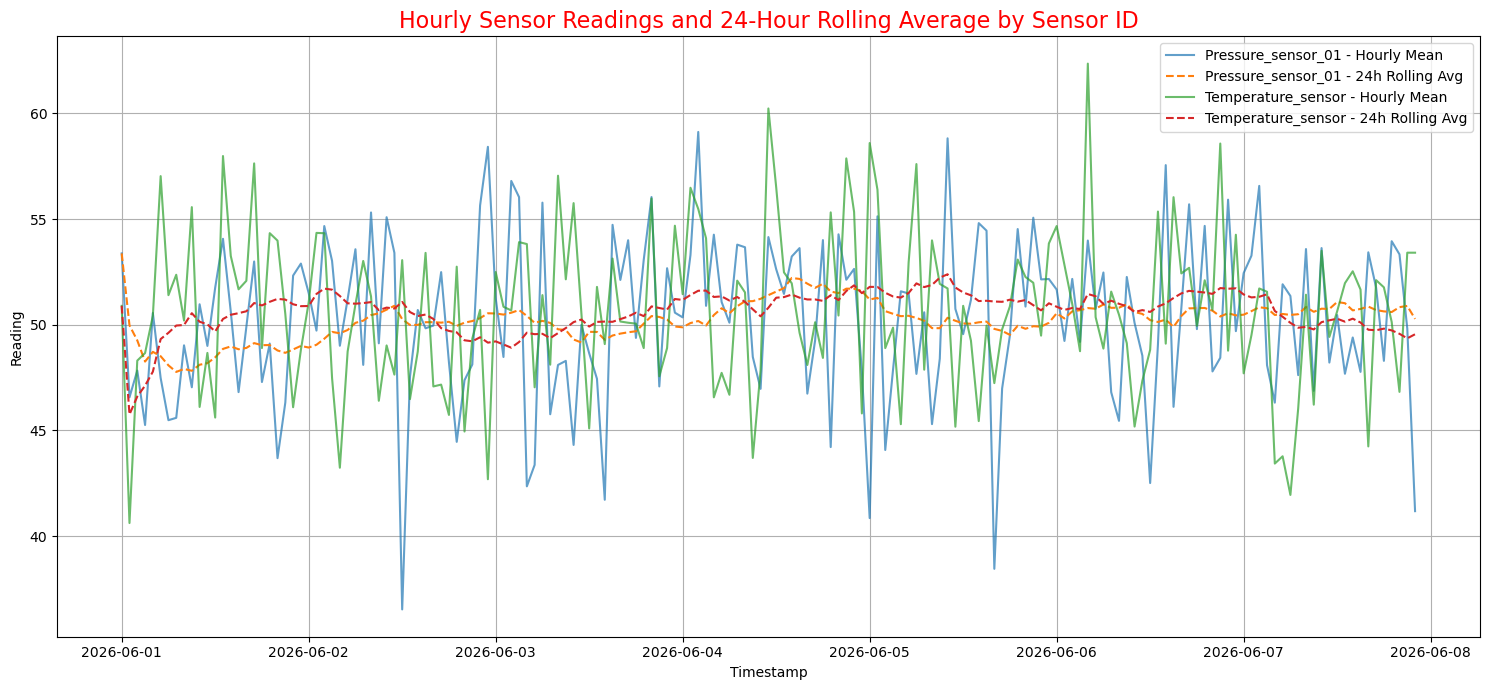

In [13]:
# Calculate a 24-hour rolling average for the 'reading' for each sensor_id
# This means we need to group by sensor_id again before applying the rolling window

hourly_resampled_df['rolling_avg_24h'] = hourly_resampled_df.groupby('sensor_id')['reading'].transform(
    lambda x: x.rolling(window=24, min_periods=1).mean()
)

print("Hourly Resampled Data with 24-Hour Rolling Average (first 10 rows):")
display(hourly_resampled_df.head(10))

# Visualize the results for one sensor_id as an example
plt.figure(figsize=(15, 7))

for sensor_id in hourly_resampled_df['sensor_id'].unique():
    sensor_data = hourly_resampled_df[hourly_resampled_df['sensor_id'] == sensor_id]
    plt.plot(sensor_data['timestamp'], sensor_data['reading'], label=f'{sensor_id} - Hourly Mean', alpha=0.7)
    plt.plot(sensor_data['timestamp'], sensor_data['rolling_avg_24h'], label=f'{sensor_id} - 24h Rolling Avg', linestyle='--')

plt.title('Hourly Sensor Readings and 24-Hour Rolling Average by Sensor ID', fontsize=16, color='red')
plt.xlabel('Timestamp')
plt.ylabel('Reading')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

***4. Aggregation: Summary Table by Shift and Zone***

**Now, let's create a summary table that shows the Mean, Max, and Min reading values for each 'Shift' and 'Zone' (which corresponds to the location column in our cleaned data)**

In [9]:
summary_table = cleaned_sensor_df.groupby(['shift', 'location'])['reading'].agg(['mean', 'max', 'min'])
display(summary_table)

mean        max        min
shift     location                                 
afternoon Kisumu    50.297098  74.457520  31.637946
          Mombasa   49.786334  74.929995  17.587327
          Nairobi   49.850291  76.323821  21.037446
morning   Kisumu    51.671811  75.600845  20.786495
          Mombasa   50.715324  81.931076  20.596114
          Nairobi   51.164419  88.527315  23.490302
night     Kisumu    50.352631  71.573082  25.761207
          Mombasa   50.840664  76.443433  24.089577
          Nairobi   49.814564  75.895636  22.967677

***5. Visualization: Raw vs. Cleaned Data Trend Over Time***

***To visualize the impact of the cleaning process, we will plot the raw data trend against the cleaned data trend over time. For a clearer comparison, we'll aggregate both the original and cleaned data to an hourly mean for a specific `sensor_id` (e.g., `pressure_sensor`). This will help us see how the cleaning steps, such as outlier removal and standardization, affect the overall trend.***

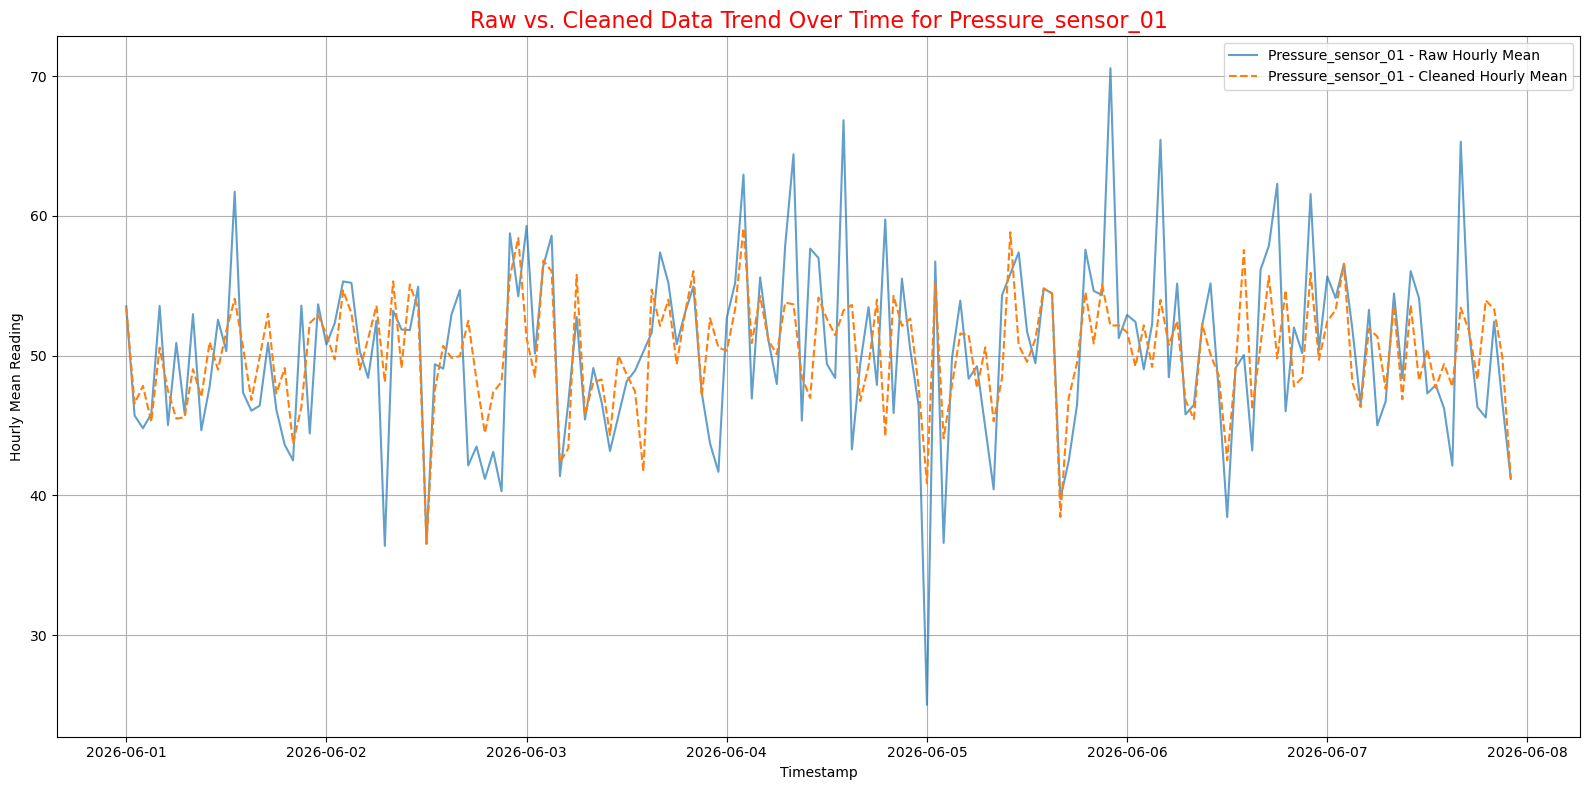

In [14]:
# Prepare original raw data for plotting: convert timestamp and standardize sensor_id
raw_df_copy = sensor_df.copy()
raw_df_copy['timestamp'] = pd.to_datetime(raw_df_copy['timestamp'], format='%d/%m/%Y %H:%M')

# Standardize sensor_id in raw data to match cleaned data for filtering
raw_df_copy['sensor_id'] = raw_df_copy['sensor_id'].str.lower().replace({
    'p1': 'Pressure_sensor_01',
    'p2': 'Pressure_sensor_02',
    'temp_sensor': 'Temperature_sensor',
    'temp_sens': 'Temperature_sensor'
})

# Set timestamp as index and resample raw data to hourly mean
raw_time_series_df = raw_df_copy.set_index('timestamp')
raw_hourly_resampled_df = raw_time_series_df.groupby('sensor_id').resample('h')['reading'].mean().reset_index()

# Select a sensor_id for comparison
selected_sensor_id = 'Pressure_sensor_01'

# Filter both raw and cleaned hourly data for the selected sensor_id
raw_sensor_data = raw_hourly_resampled_df[raw_hourly_resampled_df['sensor_id'] == selected_sensor_id]
cleaned_sensor_data = hourly_resampled_df[hourly_resampled_df['sensor_id'] == selected_sensor_id]

# Plotting
plt.figure(figsize=(16, 8))
sns.lineplot(x='timestamp', y='reading', data=raw_sensor_data, label=f'{selected_sensor_id} - Raw Hourly Mean', alpha=0.7)
sns.lineplot(x='timestamp', y='reading', data=cleaned_sensor_data, label=f'{selected_sensor_id} - Cleaned Hourly Mean', linestyle='--')

plt.title(f'Raw vs. Cleaned Data Trend Over Time for {selected_sensor_id}', color='red', fontsize=16)
plt.xlabel('Timestamp')
plt.ylabel('Hourly Mean Reading')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
